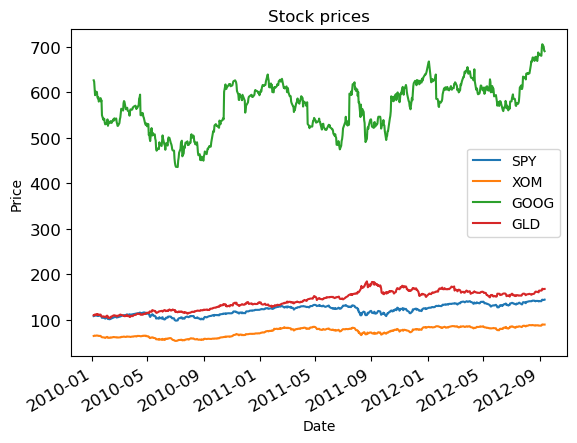

SPY     121.711206
XOM      73.296221
GOOG    568.941941
GLD     142.603279
dtype: float64
SPY     123.305
XOM      76.440
GOOG    578.845
GLD     146.440
dtype: float64
SPY     11.626556
XOM     10.168104
GOOG    54.068129
GLD     20.562938
dtype: float64


In [2]:
"""Compute Global Statistics"""

import os
import pandas as pd
import matplotlib.pyplot as plt

def symbol_to_path(symbol, base_dir="../data"):
    """Return CSV file path given ticker symbol."""
    return os.path.join(base_dir, "{}.csv".format(str(symbol)))

def get_data(symbols, dates):
    """Read stock data (adjusted close) for given symbols from CSV files."""
    df = pd.DataFrame(index=dates)
    if 'SPY' not in symbols:  # add SPY for reference, if absent
        symbols.insert(0, 'SPY')

    for symbol in symbols:
        df_temp = pd.read_csv(symbol_to_path(symbol), index_col='Date',
                parse_dates=True, usecols=['Date', 'Adj Close'], na_values=['nan'])
        df_temp = df_temp.rename(columns={'Adj Close': symbol})
        df = df.join(df_temp)
        if symbol == 'SPY':  # drop dates SPY did not trade
            df = df.dropna(subset=["SPY"])
    return df
	
def plot_data(df, title="Stock prices"):
    """Plot stock prices with a custom title and meaningful axis labels."""
    ax = df.plot(title=title, fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    plt.show()

def test_run():
	# Read data
	dates = pd.date_range('2010-01-01', '2012-12-31')
	symbols = ['SPY', 'XOM', 'GOOG', 'GLD']
	df = get_data(symbols, dates)
	plot_data(df)
	
	# Compute global statistics for each stock
	print (df.mean())
	print (df.median())
	print (df.std())

test_run()

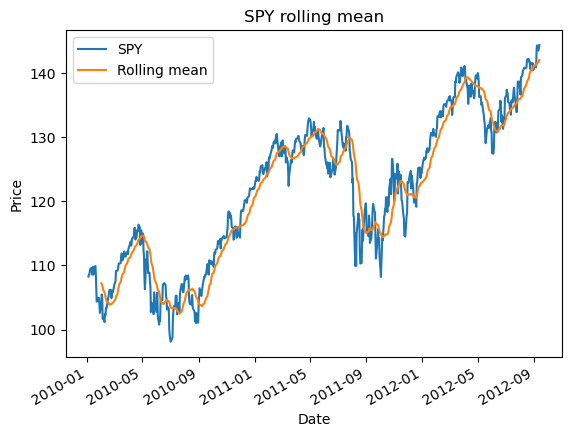

In [4]:
"""Computing Rolling Statistics"""

import os
import pandas as pd
import matplotlib.pyplot as plt
	
def symbol_to_path(symbol, base_dir="../data"):
    """Return CSV file path given ticker symbol."""
    return os.path.join(base_dir, "{}.csv".format(str(symbol)))

def get_data(symbols, dates):
    """Read stock data (adjusted close) for given symbols from CSV files."""
    df = pd.DataFrame(index=dates)
    if 'SPY' not in symbols:  # add SPY for reference, if absent
        symbols.insert(0, 'SPY')

    for symbol in symbols:
        df_temp = pd.read_csv(symbol_to_path(symbol), index_col='Date',
                parse_dates=True, usecols=['Date', 'Adj Close'], na_values=['nan'])
        df_temp = df_temp.rename(columns={'Adj Close': symbol})
        df = df.join(df_temp)
        if symbol == 'SPY':  # drop dates SPY did not trade
            df = df.dropna(subset=["SPY"])
    return df	

def test_run():
	# Read data
	dates = pd.date_range('2010-01-01', '2012-12-31')
	symbols = ['SPY', 'XOM', 'GOOG', 'GLD']
	df = get_data(symbols, dates)
	
	# Plot SPY, retain matplotlib axis object
	ax = df['SPY'].plot(title="SPY rolling mean", label='SPY')
	
	# Compute rolling mean using a 20-day window
	rm_SPY = df['SPY'].rolling( window=20).mean()
	
	# Add rolling mean to same plot
	rm_SPY.plot(label='Rolling mean', ax=ax)
	
	# Add axis labels and legend
	ax.set_xlabel("Date")
	ax.set_ylabel("Price")
	ax.legend(loc='upper left')
	plt.show()
	
test_run()

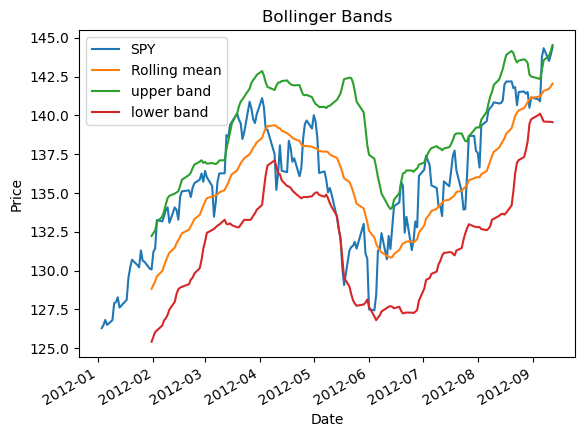

In [5]:
"""Bollinger Bands."""

def symbol_to_path(symbol, base_dir="../data"):
    """Return CSV file path given ticker symbol."""
    return os.path.join(base_dir, "{}.csv".format(str(symbol)))

def get_data(symbols, dates):
    """Read stock data (adjusted close) for given symbols from CSV files."""
    df = pd.DataFrame(index=dates)
    if 'SPY' not in symbols:  # add SPY for reference, if absent
        symbols.insert(0, 'SPY')

    for symbol in symbols:
        df_temp = pd.read_csv(symbol_to_path(symbol), index_col='Date',
                parse_dates=True, usecols=['Date', 'Adj Close'], na_values=['nan'])
        df_temp = df_temp.rename(columns={'Adj Close': symbol})
        df = df.join(df_temp)
        if symbol == 'SPY':  # drop dates SPY did not trade
            df = df.dropna(subset=["SPY"])

    return df

def plot_data(df, title="Stock prices"):
    """Plot stock prices with a custom title and meaningful axis labels."""
    ax = df.plot(title=title, fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    plt.show()

def get_rolling_mean(values, windows):
    """Return rolling mean of given values, using specified window size."""
    return values.rolling( window=windows).mean()

def get_rolling_std(values, windows):
    """Return rolling standard deviation of given values, using specified window size."""
    # Quiz: Compute and return rolling standard deviation
    return values.rolling(window=windows).std()

def get_bollinger_bands(rm, rstd):
    """Return upper and lower Bollinger Bands."""
    # Quiz: Compute upper_band and lower_band
    upper_band = rm + rstd * 2
    lower_band = rm - rstd * 2
    return upper_band, lower_band

def test_run():
    # Read data
    dates = pd.date_range('2012-01-01', '2012-12-31')
    symbols = ['SPY']
    df = get_data(symbols, dates)

    # Compute Bollinger Bands
    # 1. Compute rolling mean
    rm_SPY = get_rolling_mean(df['SPY'], windows=20)

    # 2. Compute rolling standard deviation
    rstd_SPY = get_rolling_std(df['SPY'], windows=20)

    # 3. Compute upper and lower bands
    upper_band, lower_band = get_bollinger_bands(rm_SPY, rstd_SPY)
    
    # Plot raw SPY values, rolling mean and Bollinger Bands
    ax = df['SPY'].plot(title="Bollinger Bands", label='SPY')
    rm_SPY.plot(label='Rolling mean', ax=ax)
    upper_band.plot(label='upper band', ax=ax)
    lower_band.plot(label='lower band', ax=ax)

    # Add axis labels and legend
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend(loc='upper left')
    plt.show()

test_run()

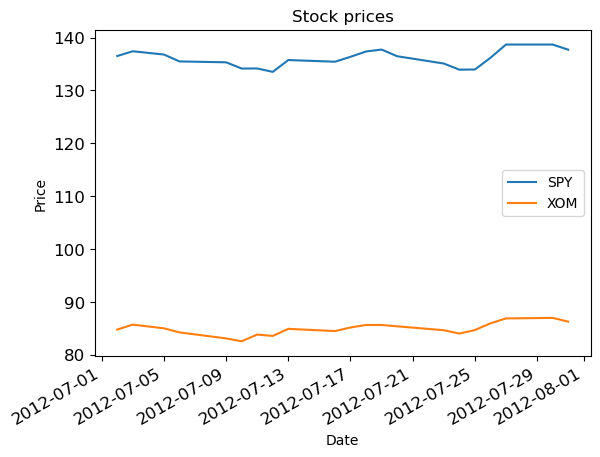

               SPY    XOM
2012-07-02  136.51  84.79
2012-07-03  137.41  85.72
2012-07-05  136.79  85.02
2012-07-06  135.49  84.25
2012-07-09  135.32  83.11
2012-07-10  134.14  82.57
2012-07-11  134.16  83.84
2012-07-12  133.51  83.58
2012-07-13  135.75  84.92
2012-07-16  135.43  84.50
2012-07-17  136.36  85.18
2012-07-18  137.37  85.65
2012-07-19  137.73  85.65
2012-07-20  136.47  85.40
2012-07-23  135.09  84.66
2012-07-24  133.93  84.03
2012-07-25  133.96  84.69
2012-07-26  136.17  85.96
2012-07-27  138.68  86.89
2012-07-30  138.68  86.99


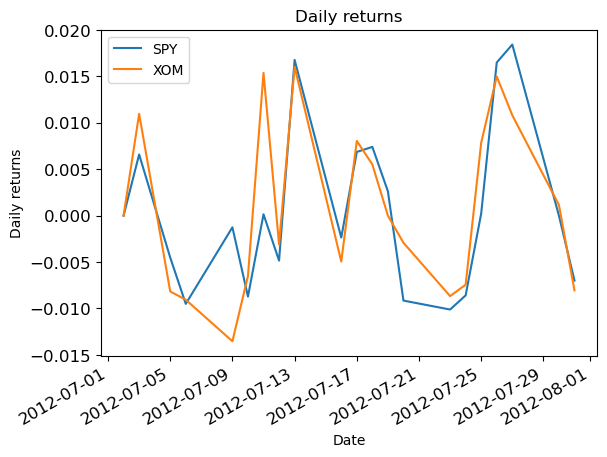

In [16]:
"""Compute daily returns."""

import os
import pandas as pd
import matplotlib.pyplot as plt

def symbol_to_path(symbol, base_dir="../data"):
    """Return CSV file path given ticker symbol."""
    return os.path.join(base_dir, "{}.csv".format(str(symbol)))

def get_data(symbols, dates):
    """Read stock data (adjusted close) for given symbols from CSV files."""
    df = pd.DataFrame(index=dates)
    if 'SPY' not in symbols:  # add SPY for reference, if absent
        symbols.insert(0, 'SPY')

    for symbol in symbols:
        df_temp = pd.read_csv(symbol_to_path(symbol), index_col='Date',
                parse_dates=True, usecols=['Date', 'Adj Close'], na_values=['nan'])
        df_temp = df_temp.rename(columns={'Adj Close': symbol})
        df = df.join(df_temp)
        if symbol == 'SPY':  # drop dates SPY did not trade
            df = df.dropna(subset=["SPY"])

    return df

def plot_data(df, title="Stock prices", xlabel="Date", ylabel="Price"):
    """Plot stock prices with a custom title and meaningful axis labels."""
    ax = df.plot(title=title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.show()

def compute_daily_returns(df):
    """Compute and return the daily return values."""
    # Quiz: Your code here
    # Note: Returned DataFrame must have the same number of rows
    daily_returns = df.copy()
    # # daily_returns[1:] = (df[1:] / df[:-1].values) - 1 # compute daily returns for row 1 onwards
    # daily_returns = (df / df.shift(1)) - 1 # much easier with Pandas!
    # daily_returns.iloc[0, :] = 0 # Pandas leaves the 0th row full of Nans
    print(df[:-1].values)
    daily_returns[1:]=(df[1:]/df[:-1].values)-1
    daily_returns.iloc[0,:] = 0
    
    return daily_returns


#      0.006593   0.010968
# 2012-07-05   -0.004512  -0.008166
# 2012-07-06   -0.009504  -0.009057
# 2012-07-09   -0.001255  -0.013531
# 2012-07-10   -0.008720  -0.006497
# 2012-07-11    0.000149   0.015381
# 2012-07-12   -0.004845  -0.003101
# 2012-07-13    0.016778   0.016033
# 2012-07-16   -0.002357  -0.004946

def test_run():
    # Read data
    dates = pd.date_range('2012-07-01', '2012-07-31')  # one month only
    symbols = ['SPY','XOM']
    df = get_data(symbols, dates)
    plot_data(df)

    # Compute daily returns
    daily_returns = compute_daily_returns(df)
    plot_data(daily_returns, title="Daily returns", ylabel="Daily returns")

test_run()